In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
housing_data=fetch_california_housing(as_frame=True)

data = housing_data.data
target = housing_data.target

x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)
importances = pd.Series(model.coef_, index=housing_data.feature_names)
results = permutation_importance(model, x_test,y_test, n_repeats=10, random_state=42)
Ip = pd.DataFrame({
    'Features': housing_data.feature_names,
    '_importances': results.importances_mean
}).sort_values(by='_importances', ascending=False)

predictions = model.predict(x_test)

mse = mean_squared_error(y_test, predictions)
R_score = r2_score(y_test, predictions)

min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())

# plt.plot([min_val, max_val], [min_val, max_val], color='blue', label='perfect fit')

# plt.scatter(y_test, predictions, alpha=0.5, color='red', label='predictions')
# plt.title('Visualization of the predictions against actual')
# plt.xlabel('y_test')
# plt.ylabel('predictions')
# plt.legend()
# plt.grid(True)
# plt.show()

print(housing_data.frame.head(3))
print(model.coef_)
print(f'\nimportances:\n{importances.sort_values(ascending=False)}')
print(f'P_imporatances: \n{Ip}')
print(f'\npredictions: {predictions[:3]}')
print(f'\nmse: {mse}\nrmse: {np.sqrt(mse)}\nR_score: {R_score}')

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
[ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]

importances:
AveBedrms     0.783145
MedInc        0.448675
HouseAge      0.009724
Population   -0.000002
AveOccup     -0.003526
AveRooms     -0.123323
Latitude     -0.419792
Longitude    -0.433708
dtype: float64
P_imporatances: 
     Features  _importances
6    Latitude      1.218143
7   Longitude      1.147945
0      MedInc      1.038924
3   AveBedrms      0.264952
2    AveRooms      0.234098
1    HouseAge      0.022112
5    AveOccup      0.00101

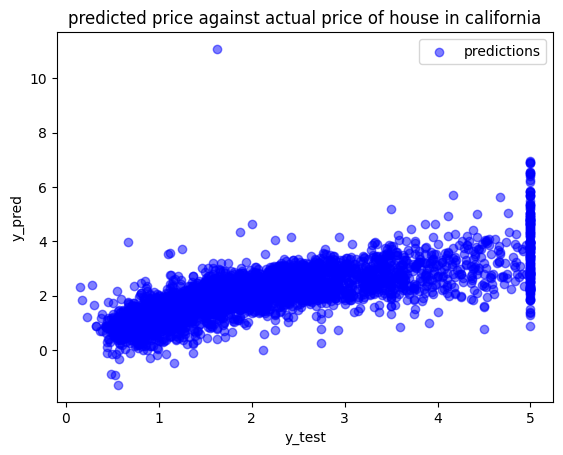

importances: 
MedInc       0.831935
Latitude    -0.984562
Longitude   -0.964060
AveRooms    -0.299413
AveBedrms    0.339423
dtype: float64
prediction x actual: 
MedHouseVal
0.47700    0.741417
0.45800    1.780959
5.00001    2.529429
2.18600    2.945555
2.78000    2.621240
dtype: float64
rmse: 0.7528409640011294
r_score: 0.5674865431409174


In [ ]:
from sklearn.preprocessing import StandardScaler


housing_data =  fetch_california_housing(as_frame=True)
data = housing_data.data
data = data[['MedInc', 'Latitude', 'Longitude', 'AveRooms', 'AveBedrms']]
target = housing_data.target

x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

scale = StandardScaler()
x_train_scaled = scale.fit_transform(x_train)
x_test_scaled =scale.transform(x_test)

model = LinearRegression()
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r_score = r2_score(y_test, y_pred)

importances = pd.Series(model.coef_, index=list(data.columns))
predictions = pd.Series(y_pred, index=y_test)

plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='predictions')
plt.title('predicted price against actual price of house in california')
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.legend()
plt.show()


print(f'importances: \n{importances}')
print(f'prediction x actual: \n{predictions.head()}')
print(f'rmse: {np.sqrt(mse)}')
print(f'r_score: {r_score}')


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
from collections import Counter

housing_data = fetch_california_housing(as_frame=True)
data = housing_data.data
target = housing_data.target

y_class = (target>3).astype(int)

x_train, x_test, y_train, y_test = train_test_split(data, y_class, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)

importances = rf.feature_importances_
Importances = pd.Series(importances, index=list(data.columns)).sort_values(ascending=False)

nodes = list([tree.tree_.node_count] for tree in rf.estimators_)
thresholds = [[tree.tree_.threshold[640:647]] for tree in rf.estimators_]
feature_index = [tree.tree_.feature[tree.tree_.feature != -2] for tree in rf.estimators_]
features_split = [data.columns[i] for i in [feature_index[j] for j in range(len([feature_index[k] for k in range(100)]))]]
features_split = [list(i) for i in features_split]
features_count = []
for i in range(100):
    features_count.append(np.unique_counts(features_split[i]))


values = [features_count[i][1] for i in range(100)]
unique = [features_count[j][0] for j in range(100)][0]

tb = pd.DataFrame(values, columns=unique[0:8])
t = sum(tb[data.columns[0]])
to = [sum(tb[data.columns[i]]) for i in range(len(data.columns))]

feature_total = pd.Series(to, index=data.columns)

score = rf.score(x_test, y_test)



features_indexes = [f for tree in rf.estimators_ for f in tree.tree_.feature if f != -2]

all_features = Counter([data.columns[i] for i in features_indexes])
_table = pd.Series(all_features).sort_values(ascending=False)

# print(f'accuracy: {accuracy_score(y_test, y_pred):.4f}')
# print(f'confusion matrix: {confusion_matrix(y_test, y_pred)}')
# print(f'score: {score:.4f}')
# print(f'importances: \n{Importances}')
# print(f'nodes_count: {nodes}')
# # print(f'feature_index:\n{feature_index[:2]}')
print(f'features_split:\n{features_split[:2]}')
# # print(len(features_split[0][1]))
# # print(values[:4])
# # print(unique[0:8])
print(f'all_features: \n{all_features}')
print(f'\n_table: \n{_table}')
# print(f't: {t}\n')
# print(f'to: {to}')
print(f'feature_total: \n{feature_total.sort_values(ascending=False)}')
# print(f'medinc_sum: {sum(tb.MedInc)}, HouseAge: {sum(tb.HouseAge)}')
# print(f'\ntb: \n{tb.head()}')
# print(f'\ntb: \n{tb.head().T}')



features_split:
[['AveOccup', 'AveRooms', 'HouseAge', 'AveOccup', 'Latitude', 'MedInc', 'Population', 'AveRooms', 'AveRooms', 'Population', 'Latitude', 'Longitude', 'Population', 'Longitude', 'Latitude', 'Latitude', 'MedInc', 'HouseAge', 'MedInc', 'Longitude', 'Longitude', 'AveOccup', 'MedInc', 'Longitude', 'Population', 'Latitude', 'Population', 'Longitude', 'Longitude', 'Population', 'MedInc', 'Population', 'Latitude', 'MedInc', 'MedInc', 'Latitude', 'AveRooms', 'AveOccup', 'AveRooms', 'Latitude', 'MedInc', 'MedInc', 'Latitude', 'MedInc', 'Population', 'Population', 'AveRooms', 'AveOccup', 'Longitude', 'Latitude', 'HouseAge', 'MedInc', 'AveBedrms', 'Population', 'Longitude', 'AveRooms', 'Population', 'Population', 'Longitude', 'AveBedrms', 'AveRooms', 'Latitude', 'MedInc', 'Population', 'AveRooms', 'Latitude', 'HouseAge', 'Population', 'AveRooms', 'AveBedrms', 'AveRooms', 'Population', 'Longitude', 'Latitude', 'AveOccup', 'AveOccup', 'MedInc', 'AveOccup', 'AveBedrms', 'AveRooms', 'Av

In [6]:
np.random.seed(42)
x = np.random.rand(6,1).flatten()

x_series = pd.Series(x)

print(x)
print(f'x_series: \n{x_series}')

[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452]
x_series: 
0    0.374540
1    0.950714
2    0.731994
3    0.598658
4    0.156019
5    0.155995
dtype: float64


In [10]:
root_indices = [tree.tree_.feature[0] for tree in rf.estimators_]

root_features = [data.columns[i] for i in root_indices]

count = Counter(root_features)
root_table = pd.Series(count, index=data.columns).sort_values(ascending=False)

print(root_table)

AveRooms      27.0
MedInc        23.0
AveOccup      19.0
HouseAge       9.0
Latitude       9.0
Longitude      9.0
Population     4.0
AveBedrms      NaN
dtype: float64


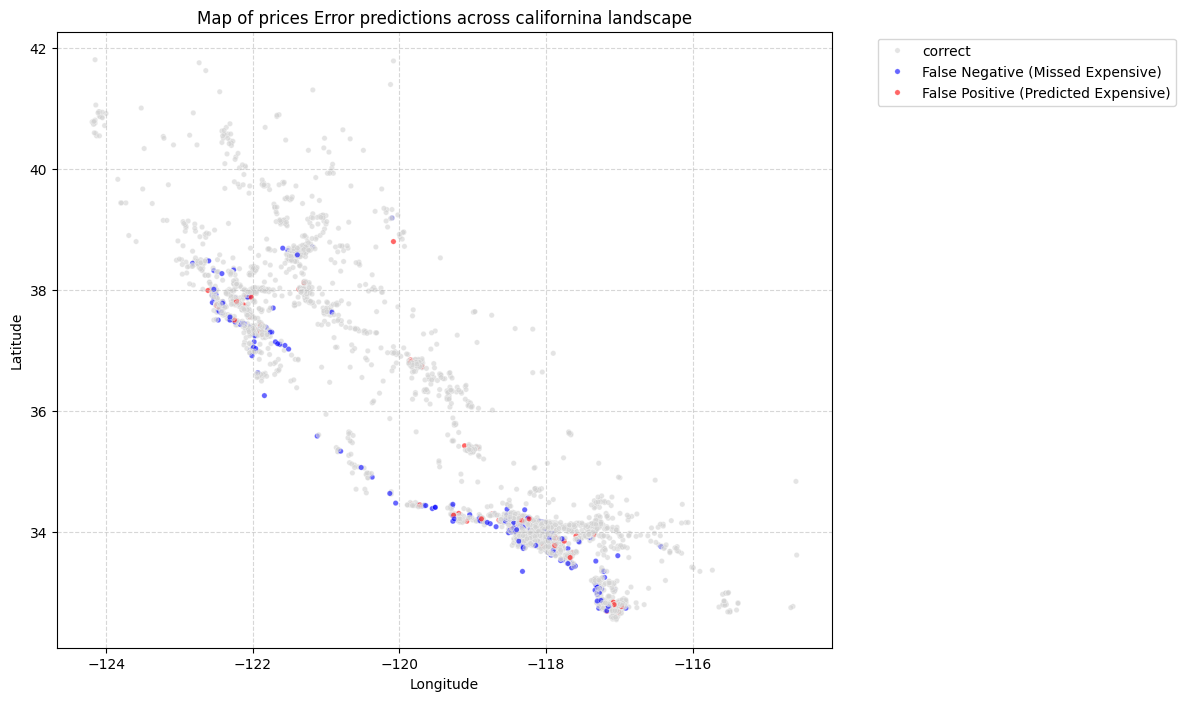

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20046  1.6812      25.0  4.192201   1.022284      1392.0  3.877437     36.06   
3024   2.5313      30.0  5.039384   1.193493      1565.0  2.679795     35.14   
15663  3.4801      52.0  3.977155   1.185877      1310.0  1.360332     37.80   
20484  5.7376      17.0  6.163636   1.020202      1705.0  3.444444     34.28   

       Longitude  actual  predicted  results  
20046    -119.01       0          0  correct  
3024     -119.46       0          0  correct  
15663    -122.44       1          1  correct  
20484    -118.72       0          0  correct  


In [15]:
import seaborn as sns

result_df = x_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = rf.predict(x_test)

def check_predictions(row):
    if row['actual'] == row['predicted']:
        return 'correct'
    elif row['actual'] == 0 and row['predicted'] == 1:
        return 'False Positive (Predicted Expensive)'
    else:
        return 'False Negative (Missed Expensive)'
    
result_df['results'] = result_df.apply(check_predictions, axis=1)

plt.figure(figsize=(10,8))
sns.scatterplot(
    result_df,
    x='Longitude',
    y='Latitude',
    hue='results',
    palette={
        'correct':'lightgrey',
        'False Positive (Predicted Expensive)':'red', 
        'False Negative (Missed Expensive)':'blue'
    },
alpha=0.6,
s=15
)

plt.title('Map of prices Error predictions across californina landscape')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
print(result_df[:4])